In [ ]:
# Market Basket Analysis
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# Set the seed for reproducibility
np.random.seed(42)

# Generate random data for market basket analysis
num_transactions = 500
num_items = 10  # 10 different products

# Randomly generate customer transactions
# Each customer can buy 1 to 5 items from the list of 10 products
product_list = ['ProductA', 'ProductB', 'ProductC', 'ProductD', 'ProductE',
                'ProductF', 'ProductG', 'ProductH', 'ProductI', 'ProductJ']

# Create a function to simulate customer purchases
def generate_transactions(num_transactions, num_items):
    transactions = []
    for _ in range(num_transactions):
        num_products = np.random.randint(1, 6)  # Each customer buys 1 to 5 items
        purchased_items = np.random.choice(product_list, num_products, replace=False)
        transactions.append(purchased_items)
    return transactions

# Generate the dataset of transactions
transactions = generate_transactions(num_transactions, num_items)

# Create a DataFrame where each row represents a transaction
# Each column will represent a product, and the value will be 1 if the product is purchased, 0 otherwise.
transaction_matrix = np.zeros((num_transactions, num_items))

# Fill the transaction matrix with the product purchases
for i, transaction in enumerate(transactions):
    for product in transaction:
        product_index = product_list.index(product)
        transaction_matrix[i, product_index] = 1

# Create a DataFrame for the transaction data
transaction_df = pd.DataFrame(transaction_matrix, columns=product_list)

# Save to CSV
transaction_df.to_csv('market_basket_analysis.csv', index=False)


In [ ]:
# Display the first few rows of the dataset
transaction_df.head()

,ProductA,ProductB,ProductC,ProductD,ProductE,ProductF,ProductG,ProductH,ProductI,ProductJ
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# {"summary":"{\n  \"name\": \"transaction_df\",\n  \"rows\": 500,\n  \"fields\": [\n    {\n      \"column\": \"ProductA\",\n      \"properties\": {\n        \"dtype\": \"number\",\n        \"std\": 0.447464466631481,\n        \"min\": 0.0,\n        \"max\": 1.0,\n        \"num_unique_values\": 2,\n        \"samples\": [\n          0.0,\n          1.0\n        ],\n        \"semantic_type\": \"\",\n        \"description\": \"\"\n      }\n    },\n    {\n      \"column\": \"ProductB\",\n      \"properties\": {\n        \"dtype\": \"number\",\n        \"std\": 0.46295643133520864,\n        \"min\": 0.0,\n        \"max\": 1.0,\n        \"num_unique_values\": 2,\n        \"samples\": [\n          1.0,\n          0.0\n        ],\n        \"semantic_type\": \"\",\n        \"description\": \"\"\n      }\n    },\n    {\n      \"column\": \"ProductC\",\n      \"properties\": {\n        \"dtype\": \"number\",\n        \"std\": 0.45234193532426786,\n        \"min\": 0.0,\n        \"max\": 1.0,\n        \"num_unique_values\": 2,\n        \"samples\": [\n          1.0,\n          0.0\n        ],\n        \"semantic_type\": \"\",\n        \"description\": \"\"\n      }\n    },\n    {\n      \"column\": \"ProductD\",\n      \"properties\": {\n        \"dtype\": \"number\",\n        \"std\": 0.44746446663148043,\n        \"min\": 0.0,\n        \"max\": 1.0,\n        \"num_unique_values\": 2,\n        \"samples\": [\n          0.0,\n          1.0\n        ],\n        \"semantic_type\": \"\",\n        \"description\": \"\"\n      }\n    },\n    {\n      \"column\": \"ProductE\",\n      \"properties\": {\n        \"dtype\": \"number\",\n        \"std\": 0.4653785064961831,\n        \"min\": 0.0,\n        \"max\": 1.0,\n        \"num_unique_values\": 2,\n        \"samples\": [\n          1.0,\n          0.0\n        ],\n        \"semantic_type\": \"\",\n        \"description\": \"\"\n      }\n    },\n    {\n      \"column\": \"ProductF\",\n      \"properties\": {\n        \"dtype\": \"number\",\n        \"std\": 0.4645811784206134,\n        \"min\": 0.0,\n        \"max\": 1.0,\n        \"num_unique_values\": 2,\n        \"samples\": [\n          1.0,\n          0.0\n        ],\n        \"semantic_type\": \"\",\n        \"description\": \"\"\n      }\n    },\n    {\n      \"column\": \"ProductG\",\n      \"properties\": {\n        \"dtype\": \"number\",\n        \"std\": 0.4513884170047052,\n        \"min\": 0.0,\n        \"max\": 1.0,\n        \"num_unique_values\": 2,\n        \"samples\": [\n          1.0,\n          0.0\n        ],\n        \"semantic_type\": \"\",\n        \"description\": \"\"\n      }\n    },\n    {\n      \"column\": \"ProductH\",\n      \"properties\": {\n        \"dtype\": \"number\",\n        \"std\": 0.4454355460123291,\n        \"min\": 0.0,\n        \"max\": 1.0,\n        \"num_unique_values\": 2,\n        \"samples\": [\n          1.0,\n          0.0\n        ],\n        \"semantic_type\": \"\",\n        \"description\": \"\"\n      }\n    },\n    {\n      \"column\": \"ProductI\",\n      \"properties\": {\n        \"dtype\": \"number\",\n        \"std\": 0.47350227963298586,\n        \"min\": 0.0,\n        \"max\": 1.0,\n        \"num_unique_values\": 2,\n        \"samples\": [\n          0.0,\n          1.0\n        ],\n        \"semantic_type\": \"\",\n        \"description\": \"\"\n      }\n    },\n    {\n      \"column\": \"ProductJ\",\n      \"properties\": {\n        \"dtype\": \"number\",\n        \"std\": 0.4653785064961832,\n        \"min\": 0.0,\n        \"max\": 1.0,\n        \"num_unique_values\": 2,\n        \"samples\": [\n          0.0,\n          1.0\n        ],\n        \"semantic_type\": \"\",\n        \"description\": \"\"\n      }\n    }\n  ]\n}","type":"dataframe","variable_name":"transaction_df"}
# Calculate WCSS (Within-Cluster Sum of Squares) for different numbers of clusters
X =
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

NameError: name 'scaled_data' is not defined

In [ ]:
# Plot the Elbow Curve to determine the optimal K
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

In [ ]:
# Apply K-Means with the selected K (e.g., K=4)
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# Add the cluster labels to the original dataset
data['Cluster'] = clusters

# Show the first few rows with cluster labels
data.head()
# {"summary":"{\n  \"name\": \"data\",\n  \"rows\": 500,\n  \"fields\": [\n    {\n      \"column\": \"ProductA\",\n      \"properties\": {\n        \"dtype\": \"number\",\n        \"std\": 0.447464466631481,\n        \"min\": 0.0,\n        \"max\": 1.0,\n        \"num_unique_values\": 2,\n        \"samples\": [\n          0.0,\n          1.0\n        ],\n        \"semantic_type\": \"\",\n        \"description\": \"\"\n      }\n    },\n    {\n      \"column\": \"ProductB\",\n      \"properties\": {\n        \"dtype\": \"number\",\n        \"std\": 0.46295643133520864,\n        \"min\": 0.0,\n        \"max\": 1.0,\n        \"num_unique_values\": 2,\n        \"samples\": [\n          1.0,\n          0.0\n        ],\n        \"semantic_type\": \"\",\n        \"description\": \"\"\n      }\n    },\n    {\n      \"column\": \"ProductC\",\n      \"properties\": {\n        \"dtype\": \"number\",\n        \"std\": 0.45234193532426786,\n        \"min\": 0.0,\n        \"max\": 1.0,\n        \"num_unique_values\": 2,\n        \"samples\": [\n          1.0,\n          0.0\n        ],\n        \"semantic_type\": \"\",\n        \"description\": \"\"\n      }\n    },\n    {\n      \"column\": \"ProductD\",\n      \"properties\": {\n        \"dtype\": \"number\",\n        \"std\": 0.44746446663148043,\n        \"min\": 0.0,\n        \"max\": 1.0,\n        \"num_unique_values\": 2,\n        \"samples\": [\n          0.0,\n          1.0\n        ],\n        \"semantic_type\": \"\",\n        \"description\": \"\"\n      }\n    },\n    {\n      \"column\": \"ProductE\",\n      \"properties\": {\n        \"dtype\": \"number\",\n        \"std\": 0.4653785064961831,\n        \"min\": 0.0,\n        \"max\": 1.0,\n        \"num_unique_values\": 2,\n        \"samples\": [\n          1.0,\n          0.0\n        ],\n        \"semantic_type\": \"\",\n        \"description\": \"\"\n      }\n    },\n    {\n      \"column\": \"ProductF\",\n      \"properties\": {\n        \"dtype\": \"number\",\n        \"std\": 0.4645811784206134,\n        \"min\": 0.0,\n        \"max\": 1.0,\n        \"num_unique_values\": 2,\n        \"samples\": [\n          1.0,\n          0.0\n        ],\n        \"semantic_type\": \"\",\n        \"description\": \"\"\n      }\n    },\n    {\n      \"column\": \"ProductG\",\n      \"properties\": {\n        \"dtype\": \"number\",\n        \"std\": 0.4513884170047052,\n        \"min\": 0.0,\n        \"max\": 1.0,\n        \"num_unique_values\": 2,\n        \"samples\": [\n          1.0,\n          0.0\n        ],\n        \"semantic_type\": \"\",\n        \"description\": \"\"\n      }\n    },\n    {\n      \"column\": \"ProductH\",\n      \"properties\": {\n        \"dtype\": \"number\",\n        \"std\": 0.4454355460123291,\n        \"min\": 0.0,\n        \"max\": 1.0,\n        \"num_unique_values\": 2,\n        \"samples\": [\n          1.0,\n          0.0\n        ],\n        \"semantic_type\": \"\",\n        \"description\": \"\"\n      }\n    },\n    {\n      \"column\": \"ProductI\",\n      \"properties\": {\n        \"dtype\": \"number\",\n        \"std\": 0.47350227963298586,\n        \"min\": 0.0,\n        \"max\": 1.0,\n        \"num_unique_values\": 2,\n        \"samples\": [\n          0.0,\n          1.0\n        ],\n        \"semantic_type\": \"\",\n        \"description\": \"\"\n      }\n    },\n    {\n      \"column\": \"ProductJ\",\n      \"properties\": {\n        \"dtype\": \"number\",\n        \"std\": 0.4653785064961832,\n        \"min\": 0.0,\n        \"max\": 1.0,\n        \"num_unique_values\": 2,\n        \"samples\": [\n          0.0,\n          1.0\n        ],\n        \"semantic_type\": \"\",\n        \"description\": \"\"\n      }\n    },\n    {\n      \"column\": \"Cluster\",\n      \"properties\": {\n        \"dtype\": \"int32\",\n        \"num_unique_values\": 4,\n        \"samples\": [\n          2,\n          0\n        ],\n        \"semantic_type\": \"\",\n        \"description\": \"\"\n      }\n    }\n  ]\n}","type":"dataframe","variable_name":"data"}
# Analyze the frequency of products purchased by each cluster
cluster_insights = data.groupby('Cluster').mean()
print(cluster_insights)


NameError: name 'scaled_data' is not defined

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Step 1: Load the dataset (use your own path for the CSV file)
data = pd.read_csv('market_basket_analysis.csv')

# Step 2: Preprocess the data (Scale the data to normalize it)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# Step 3: Elbow Method to determine the optimal number of clusters (K)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method to find the optimal K
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Step 4: Apply K-Means with the selected number of clusters (let's assume K=4)
optimal_k = 4  # Based on the elbow plot (you can adjust this)
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# Step 5: Add the cluster labels to the original dataset
data['Cluster'] = clusters

# Step 6: Show the first few rows of the dataset with cluster labels
print(data.head())

# Step 7: Cluster insights (mean of features within each cluster)
cluster_insights = data.groupby('Cluster').mean()
print("\nCluster Insights (Average Features per Cluster):")
print(cluster_insights)



In [ ]:

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Step 1: Generate synthetic data (Retail customers with product purchase behavior)
# Assume 5 features, mimicking purchasing behavior
np.random.seed(42)

# Generate random data with three clear clusters
cluster_1 = np.random.normal(loc=[50, 200, 0.2, 30, 1], scale=10, size=(100, 5))
cluster_2 = np.random.normal(loc=[150, 300, 0.5, 50, 2], scale=15, size=(100, 5))
cluster_3 = np.random.normal(loc=[300, 500, 0.8, 80, 3], scale=20, size=(100, 5))

# Combine the clusters to form the dataset
data = np.vstack([cluster_1, cluster_2, cluster_3])

# Convert to DataFrame for better readability
columns = ['ProductA', 'ProductB', 'ProductC', 'ProductD', 'ProductE']
data_df = pd.DataFrame(data, columns=columns)

# Step 2: Preprocess the data (Scale the data to normalize it)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_df)

# Step 3: Elbow Method to determine the optimal number of clusters (K)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method to find the optimal K
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Step 4: Apply K-Means with the selected number of clusters (e.g., K=3)
optimal_k = 3  # Based on the elbow plot (K=3)
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# Step 5: Add the cluster labels to the original dataset
data_df['Cluster'] = clusters

# Step 6: Show the first few rows of the dataset with cluster labels
print(data_df.head())

# Step 7: Cluster insights (mean of features within each cluster)
cluster_insights = data_df.groupby('Cluster').mean()
print("\nCluster Insights (Average Features per Cluster):")
print(cluster_insights)

In [ ]:
project3:

In [ ]:
Customer Segmentation for Flipkart
Objective: Segment Flipkart customers based on their purchasing behavior
(ex: frequency of purchases, average order value, product categories bought) to create personalized marketing strategies and improve sales.
Step 1: Generate Synthetic Data
CustomerID: Unique ID for each customer
Age: Age of the customer
AnnualIncome: Income level of the customer
PurchaseFrequency: Number of purchases made in a year
AvgOrderValue: Average value of each order
PreferredCategory: The product category preferred by the customer (like electronics, fashion, home goods, etc.)
DiscountSensitivity: How sensitive the customer is to discounts (higher value = more sensitive)
Step 2: Apply K-Means Clustering
We'll use the Elbow Method to determine the optimal number of clusters (K) and then apply K-Means clustering to segment customers into different groups.


In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
# Step 1: Generate synthetic dataset for Flipkart customers
np.random.seed(42)

# Increase customer count to 10,000
customer_count = 10000

# Randomly generating data for features
age = np.random.randint(18, 65, customer_count)
annual_income = np.random.randint(300000, 1500000, customer_count)
purchase_frequency = np.random.randint(1, 20, customer_count)
avg_order_value = np.random.randint(500, 10000, customer_count)
preferred_category = np.random.choice(['Electronics', 'Fashion', 'HomeGoods', 'Groceries', 'Books'], customer_count)
discount_sensitivity = np.random.uniform(0.1, 1.0, customer_count)


In [5]:
# Create the dataframe
data = pd.DataFrame({
    'CustomerID': range(1, customer_count + 1),
    'Age': age,
    'AnnualIncome': annual_income,
    'PurchaseFrequency': purchase_frequency,
    'AvgOrderValue': avg_order_value,
    'PreferredCategory': preferred_category,
    'DiscountSensitivity': discount_sensitivity
})
data.head()

,CustomerID,Age,AnnualIncome,PurchaseFrequency,AvgOrderValue,PreferredCategory,DiscountSensitivity
0,1,56,576999,6,9079,Books,0.196120
1,2,46,729385,19,1297,Groceries,0.625652
2,3,32,477476,10,6213,Fashion,0.143802
3,4,60,1499217,1,7811,HomeGoods,0.944786
4,5,25,949362,16,4520,Books,0.395962


In [6]:
# Save the generated data to CSV
data.to_csv('flipkart_customers.csv', index=False)
print("Synthetic data saved to 'flipkart_customers.csv'.")

Synthetic data saved to 'flipkart_customers.csv'.


In [7]:
# Step 2: Preprocess the data (only numeric features for clustering)
numeric_data = data[['Age', 'AnnualIncome', 'PurchaseFrequency', 'AvgOrderValue', 'DiscountSensitivity']]

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_data)


In [8]:
# Step 3: Elbow Method to determine the optimal number of clusters (K)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

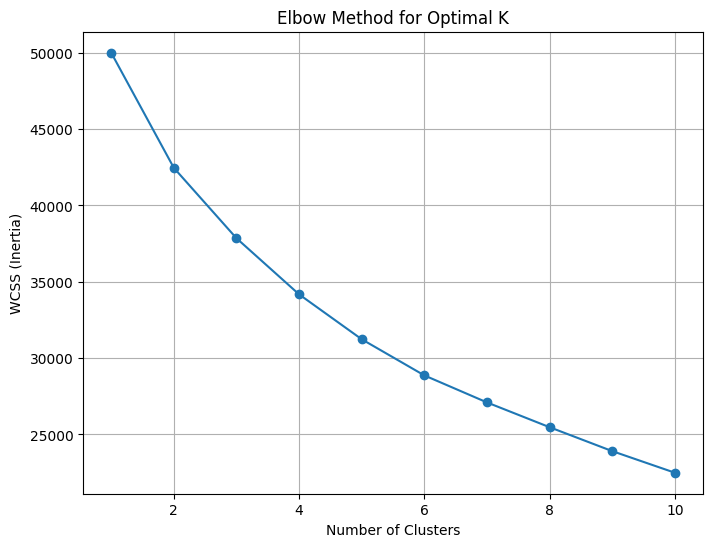

In [9]:
# Plot the Elbow Method to find the optimal K
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

In [10]:
# Step 4: Apply K-Means with the selected number of clusters (e.g., K=4)
optimal_k = 4  # Based on the elbow plot
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
data['Cluster'] = kmeans.fit_predict(scaled_data)

In [11]:
# Step 5: Show the first few rows of the dataset with cluster labels
print(data.head())

   CustomerID  Age  AnnualIncome  PurchaseFrequency  AvgOrderValue  \
0           1   56        576999                  6           9079   
1           2   46        729385                 19           1297   
2           3   32        477476                 10           6213   
3           4   60       1499217                  1           7811   
4           5   25        949362                 16           4520   

  PreferredCategory  DiscountSensitivity  Cluster  
0             Books             0.196120        2  
1         Groceries             0.625652        2  
2           Fashion             0.143802        3  
3         HomeGoods             0.944786        1  
4             Books             0.395962        0  


In [12]:
# Step 6: Cluster insights (mean of numeric features within each cluster)
# Exclude non-numeric columns like 'PreferredCategory' from aggregation
numeric_columns = ['Age', 'AnnualIncome', 'PurchaseFrequency', 'AvgOrderValue', 'DiscountSensitivity']
cluster_insights = data.groupby('Cluster')[numeric_columns].mean()

# Display the cluster insights
print("\nCluster Insights (Average Features per Cluster):")
print(cluster_insights)

# Save clustered data to CSV
data.to_csv('flipkart_clustered_customers.csv', index=False)
print("Clustered data saved to 'flipkart_clustered_customers.csv'.")


Cluster Insights (Average Features per Cluster):
               Age  AnnualIncome  PurchaseFrequency  AvgOrderValue  \
Cluster                                                              
0        33.513900  1.181457e+06          14.227413    5246.917375   
1        49.989510  1.115350e+06           5.422688    5049.810023   
2        51.628015  6.380413e+05          13.575963    5464.926788   
3        29.546704  6.406867e+05           7.045693    5198.655884   

         DiscountSensitivity  
Cluster                       
0                   0.562846  
1                   0.533552  
2                   0.558123  
3                   0.555127  
Clustered data saved to 'flipkart_clustered_customers.csv'.


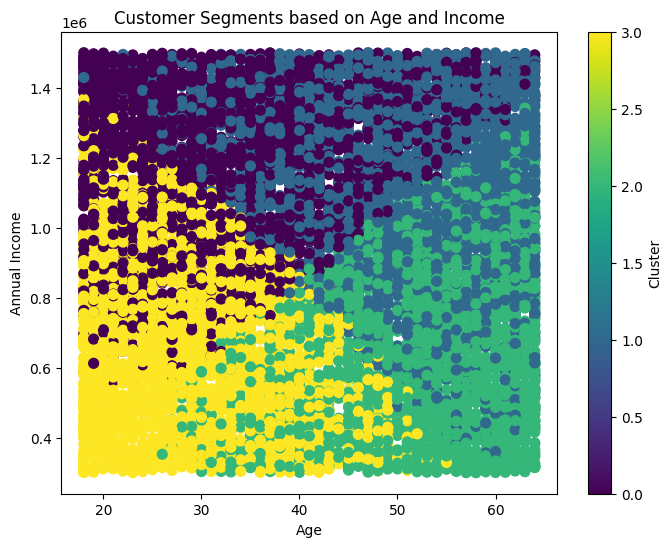

In [13]:
# Visualizing the clusters
plt.figure(figsize=(8, 6))
plt.scatter(data['Age'], data['AnnualIncome'], c=data['Cluster'], cmap='viridis', s=50)
plt.title('Customer Segments based on Age and Income')
plt.xlabel('Age')
plt.ylabel('Annual Income')
plt.colorbar(label='Cluster')
plt.show()

# THE END